# Plots

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

- Generate Pareto frontier plots using GPU and CPU evaluation data.

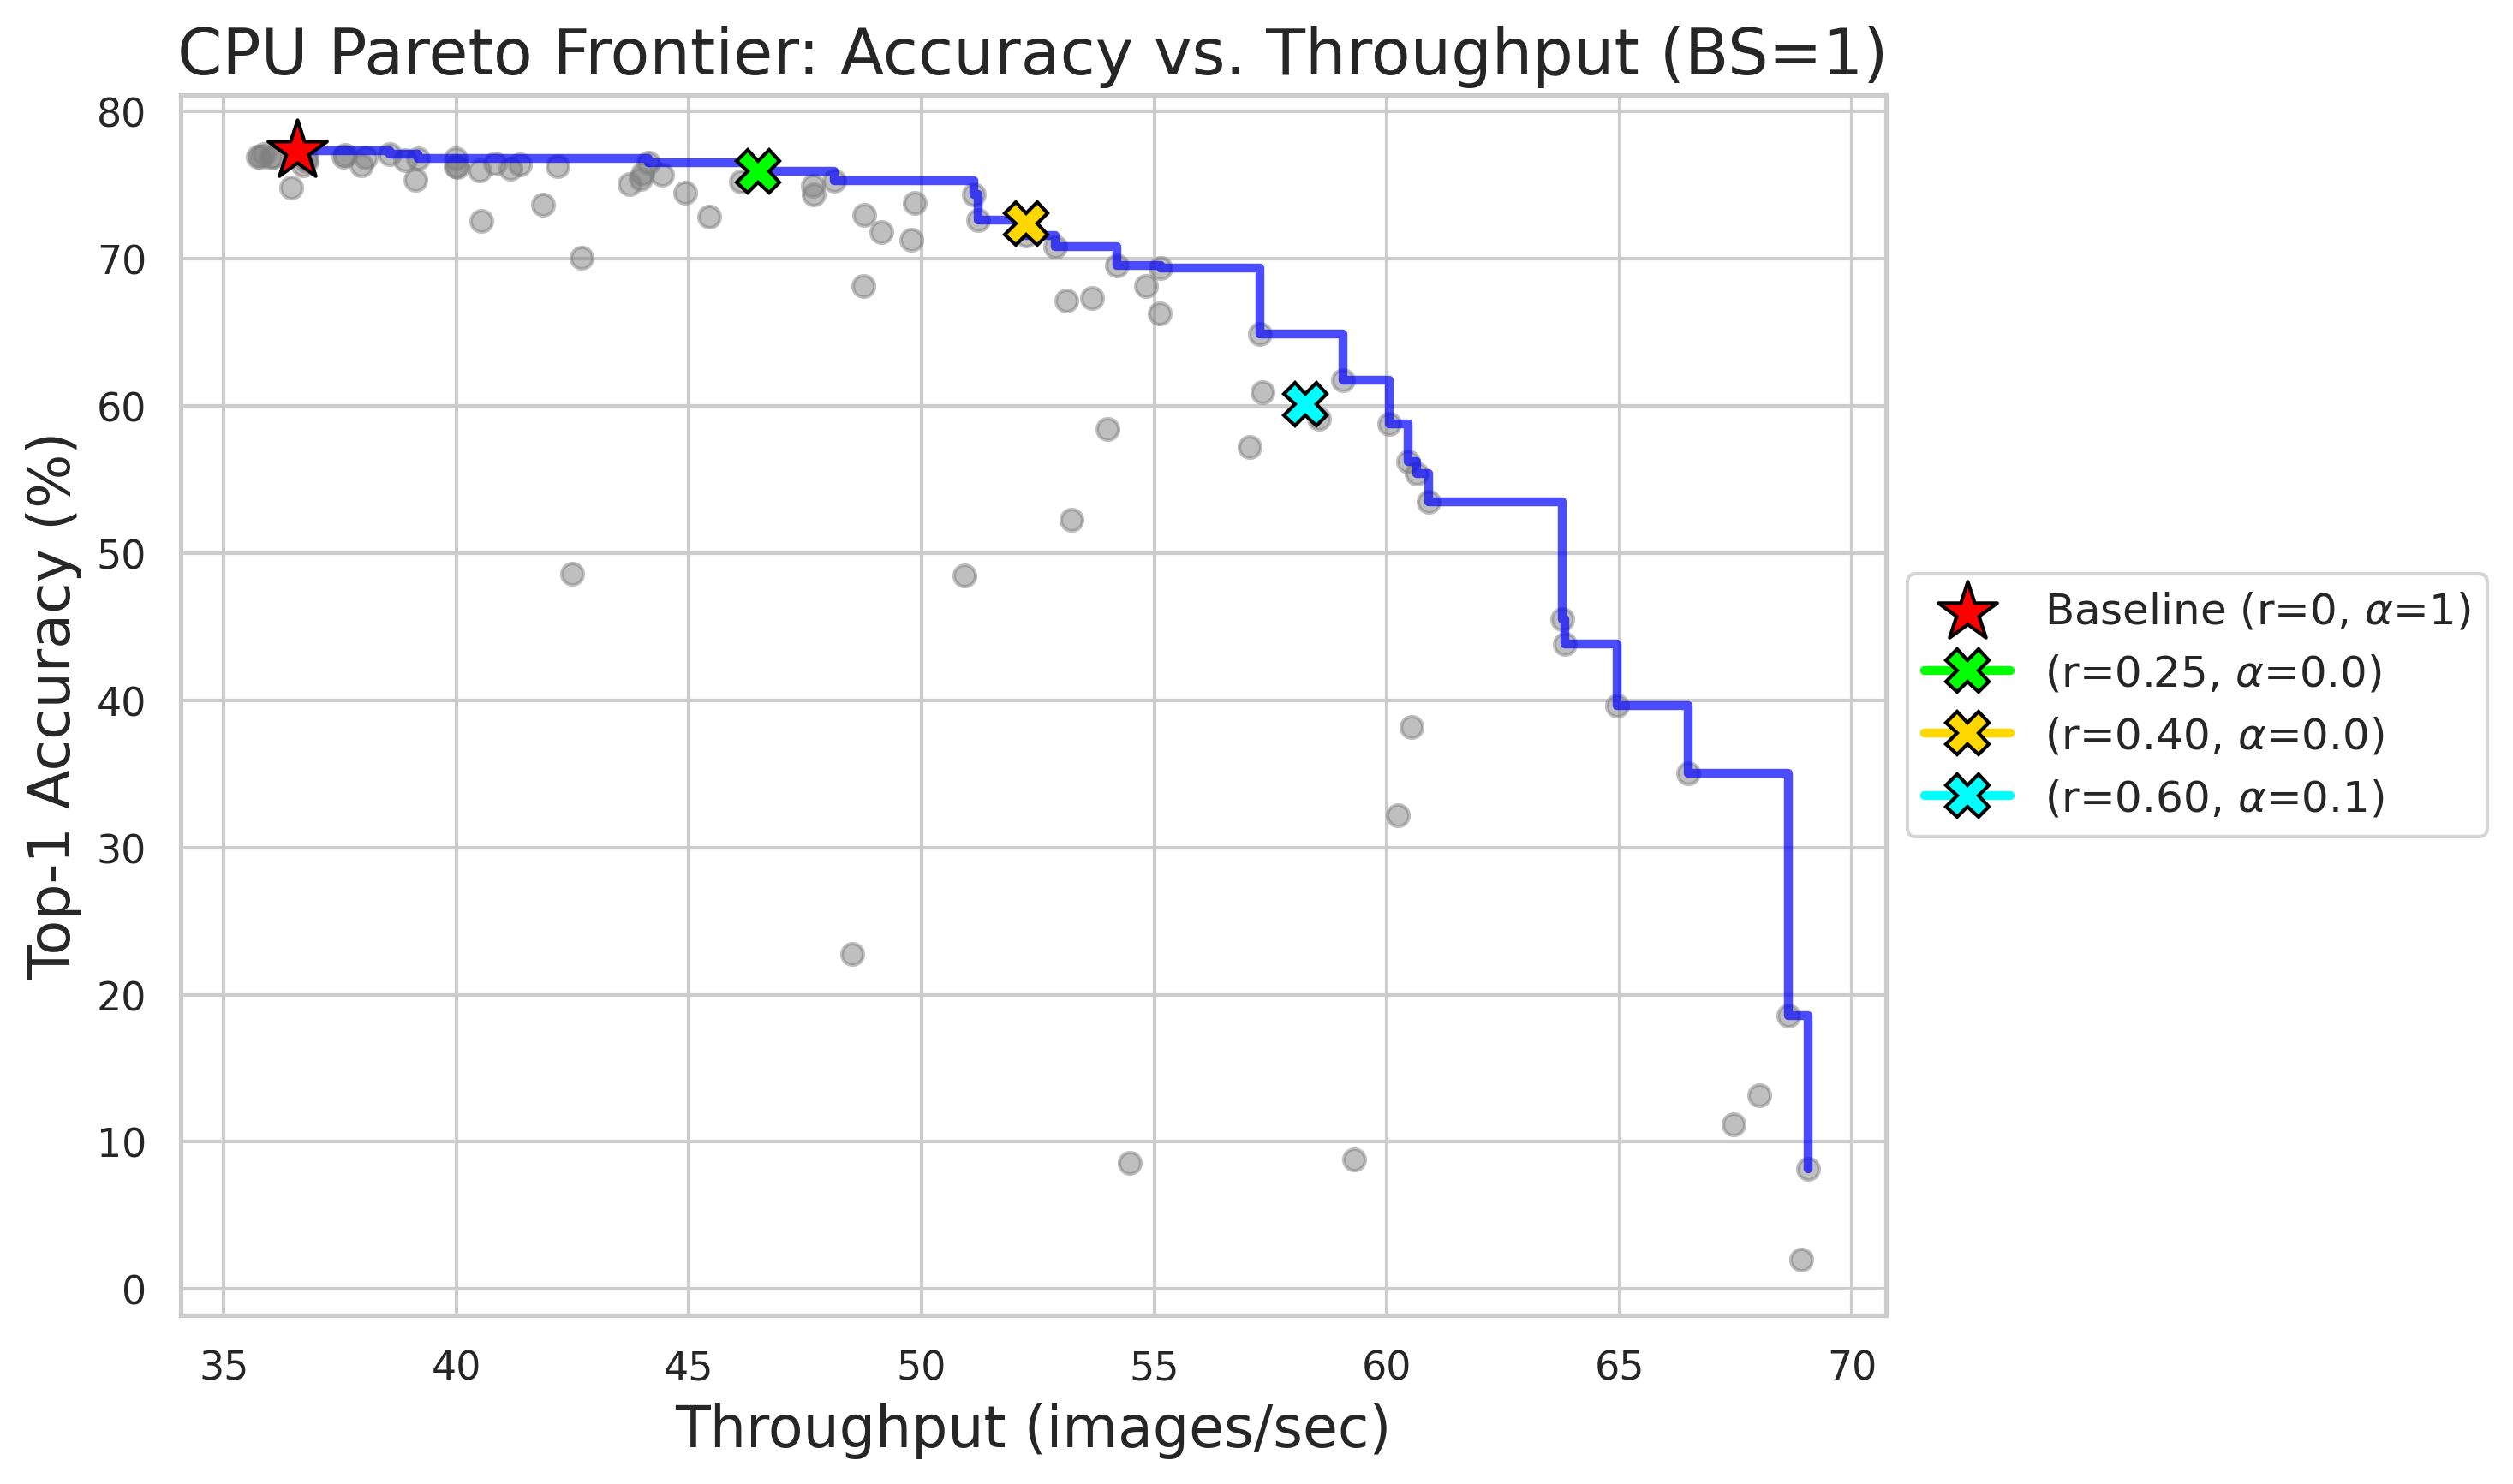

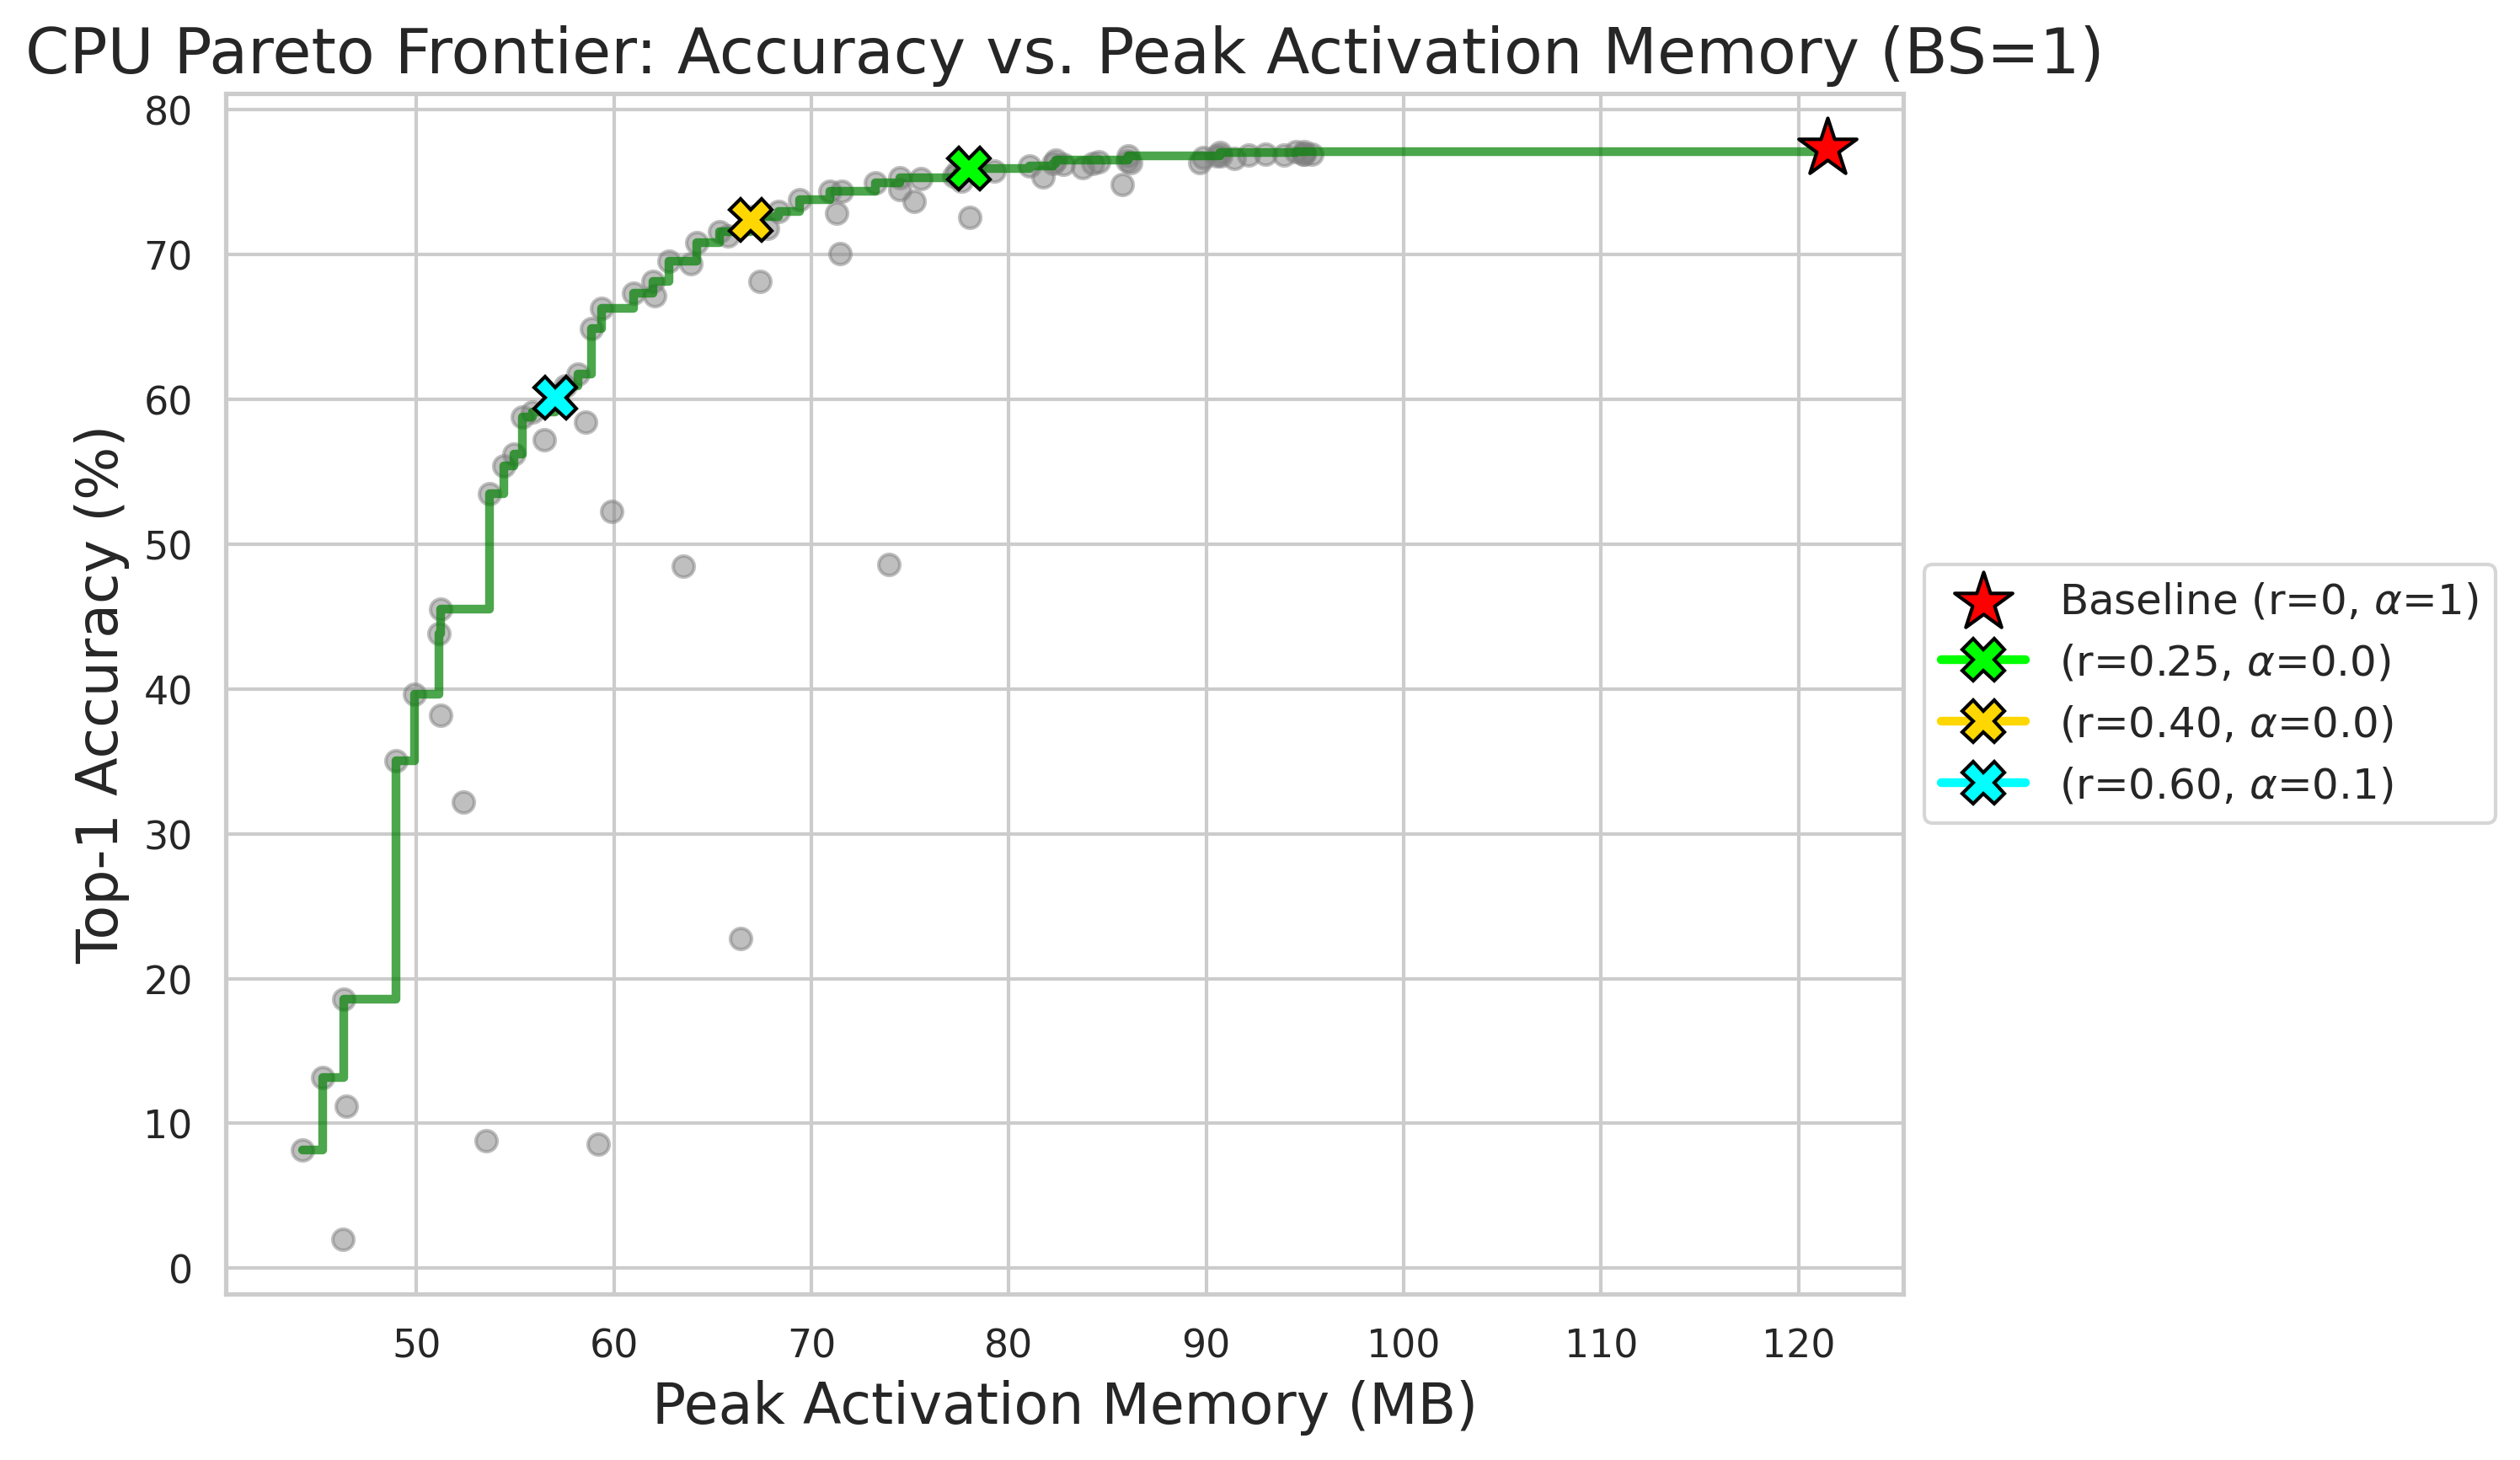

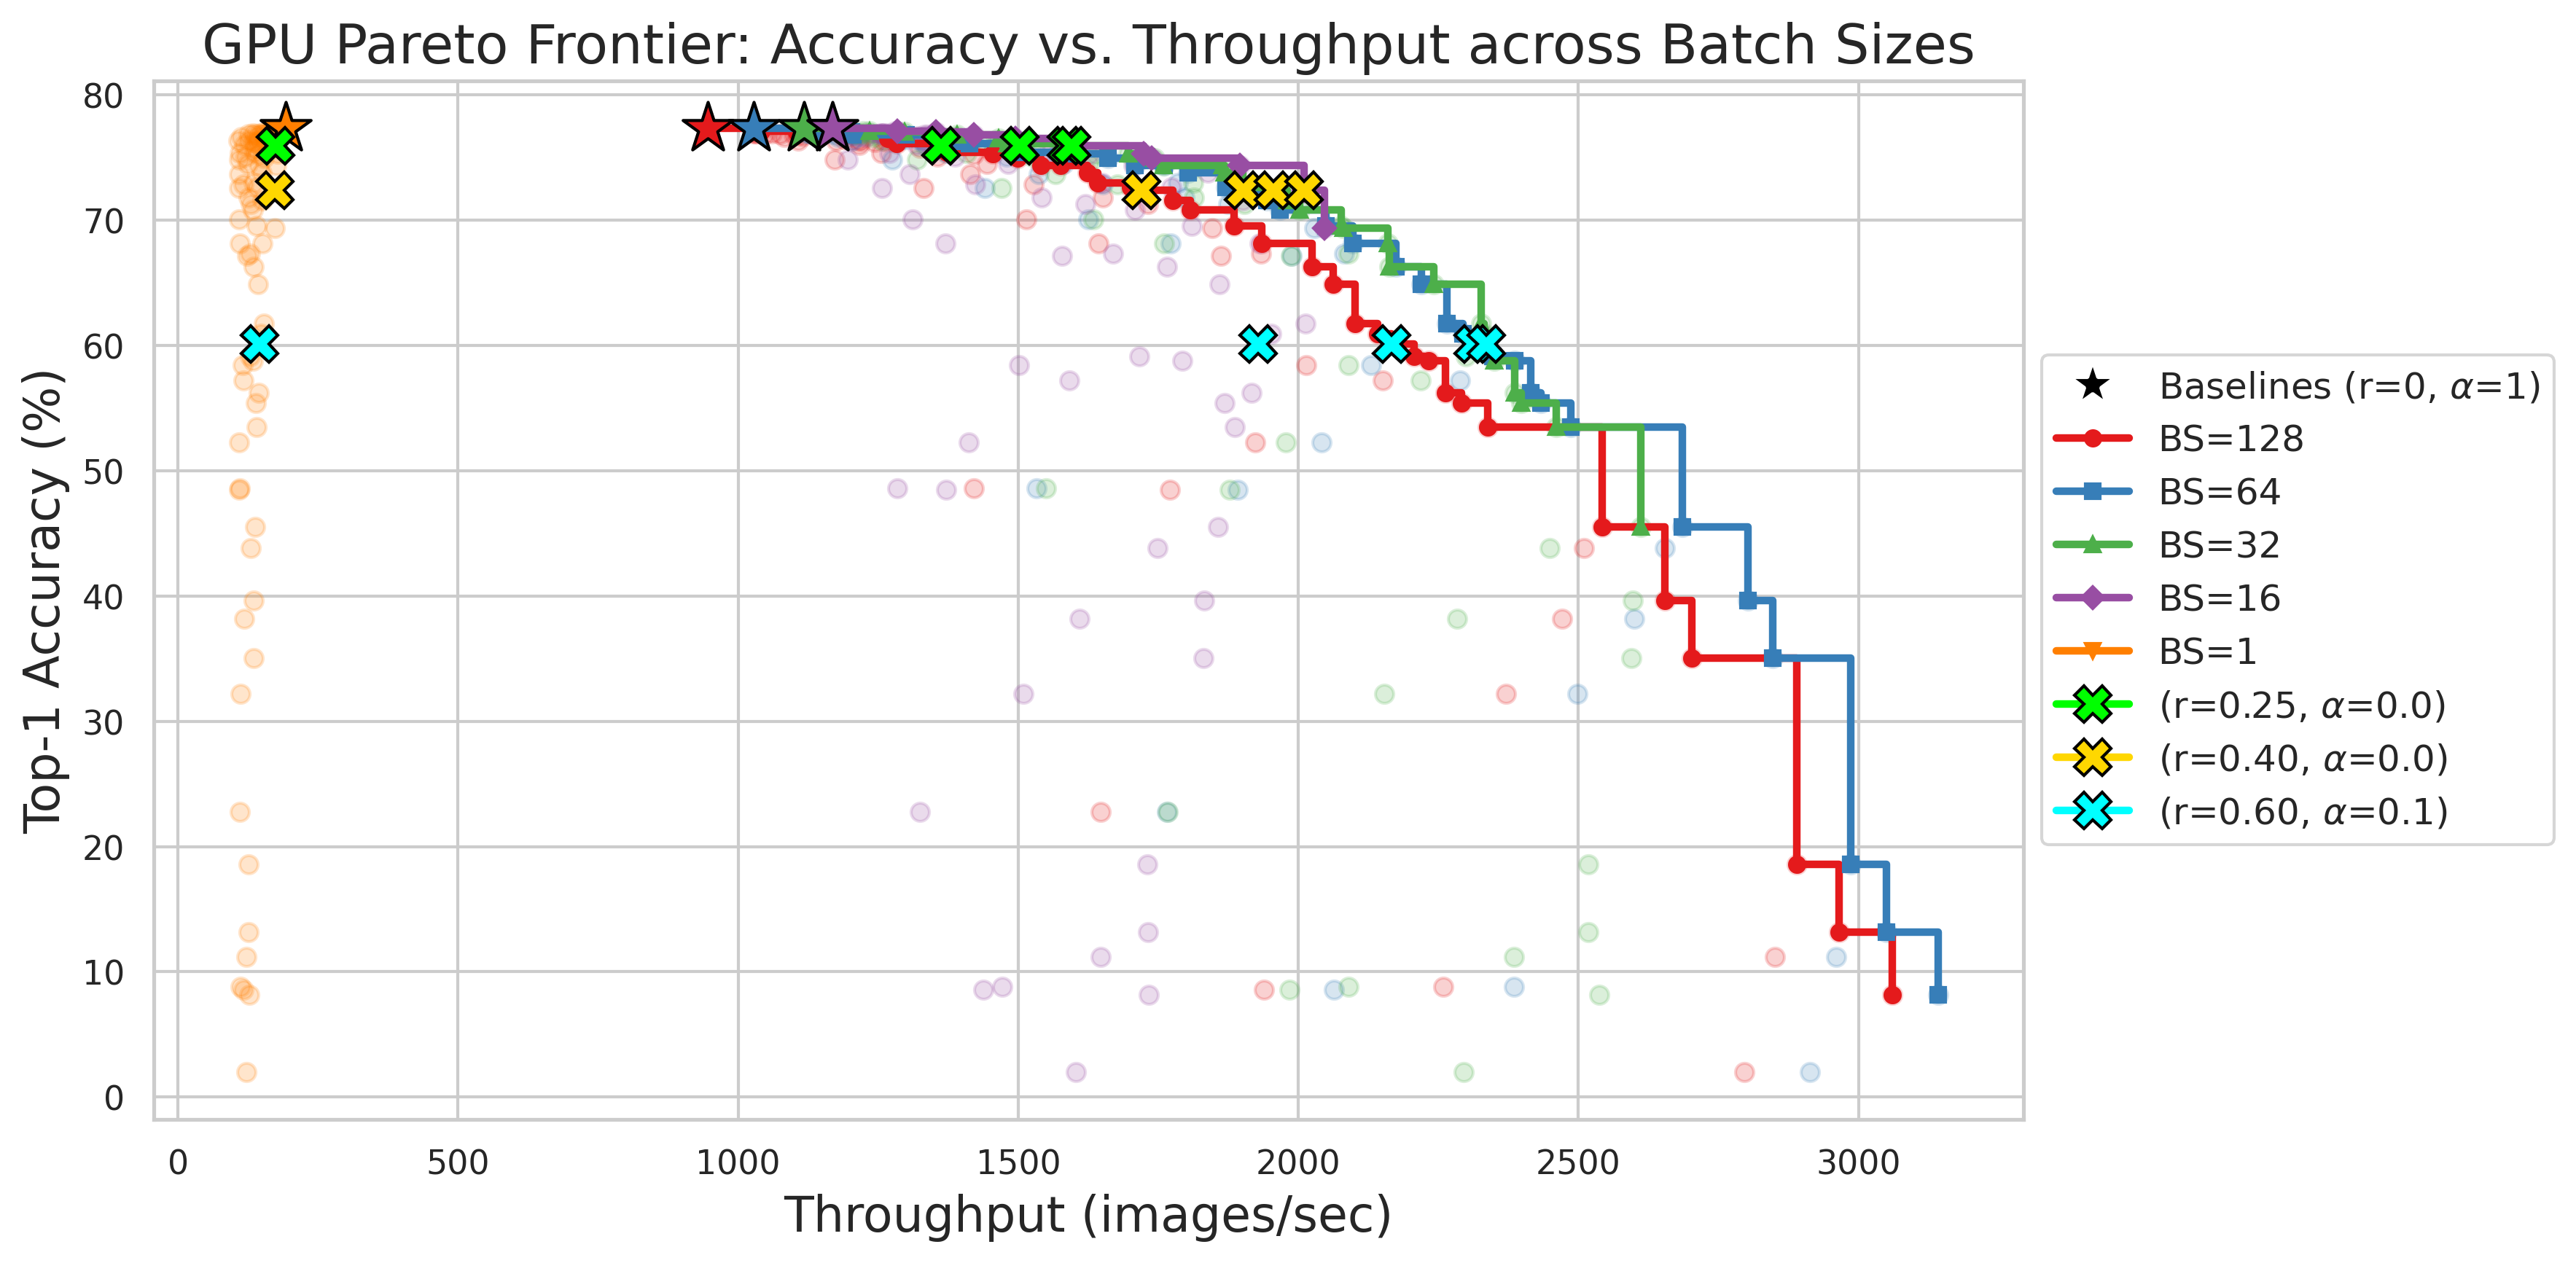

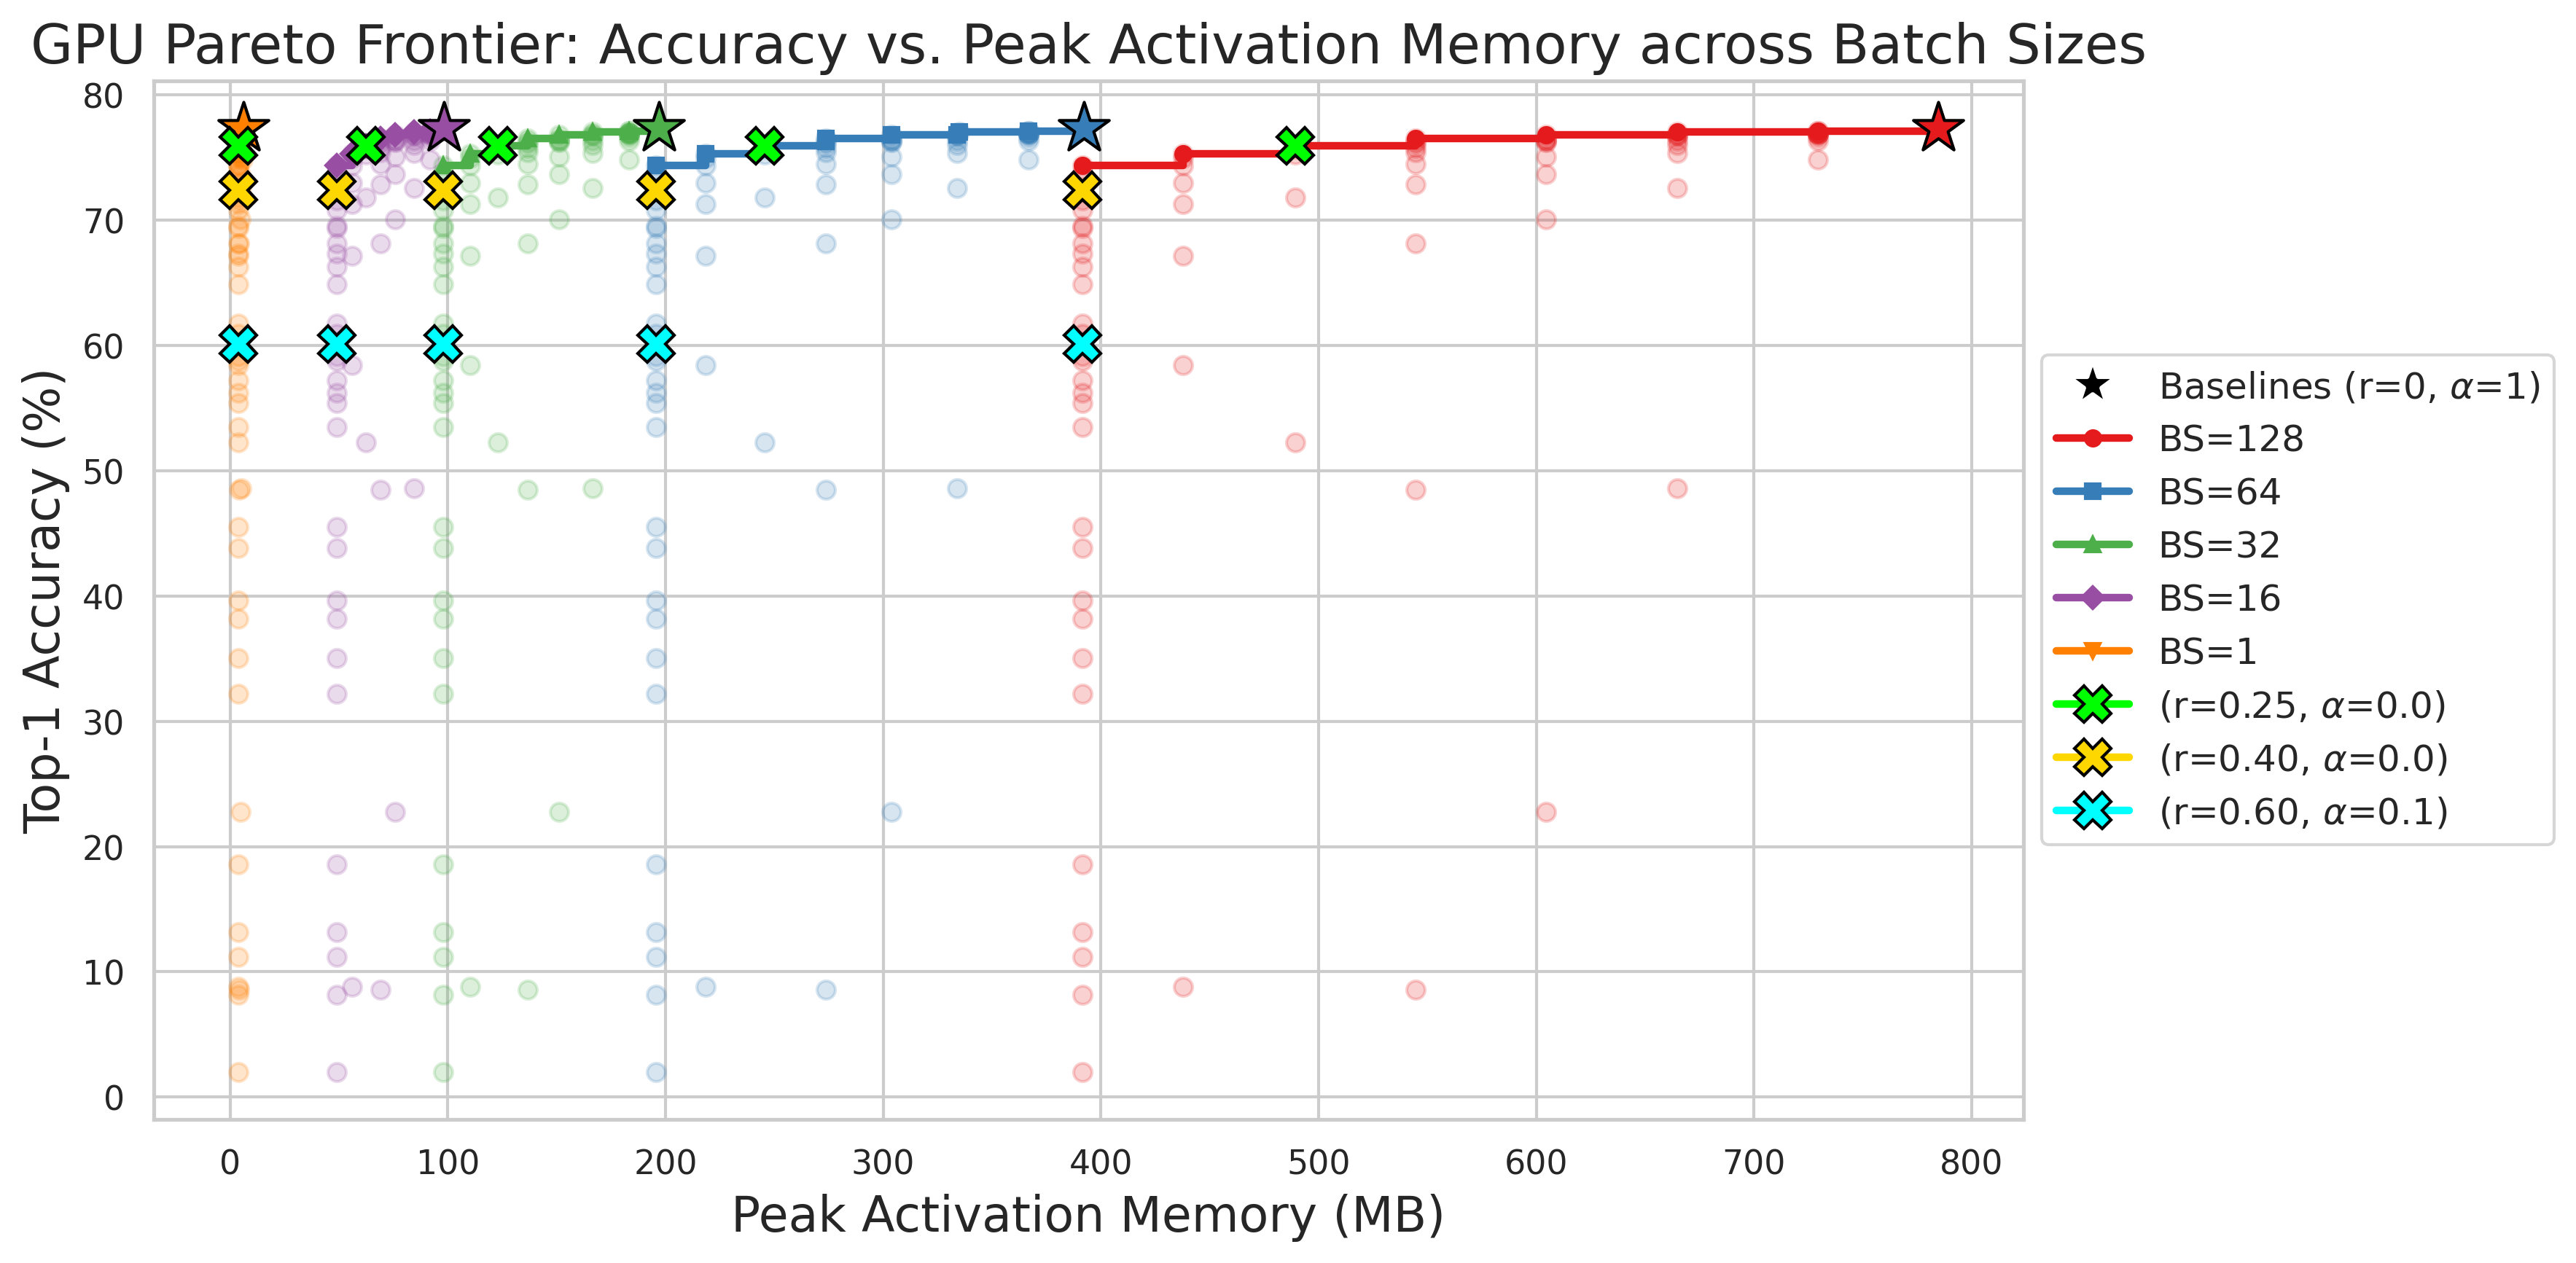

In [5]:
def get_pareto_frontier(Xs, Ys, maxX=True, maxY=True):
    """
    Calculates the Pareto optimal coordinates for plotting.

     Args:
        Xs: list of X-axis values.
        Ys: list of Y-axis values.
        maxX: whether to maximize X values.
        maxY: whether to maximize Y values.
    
    Returns:
        tuple: the Pareto frontier as lists of ordered Xs and Ys.
    """
    points = list(zip(Xs, Ys))
    # sort based on x-value or y-value
    points.sort(key=lambda p: (-p[0] if maxX else p[0], -p[1] if maxY else p[1]))
    
    # sweep the frontier
    pareto_front = [points[0]]
    for point in points[1:]:
        if maxY:
            if point[1] > pareto_front[-1][1]:
                pareto_front.append(point)
        else:
            if point[1] < pareto_front[-1][1]:
                pareto_front.append(point)
    
    # return as unziped lists
    return [p[0] for p in pareto_front], [p[1] for p in pareto_front]


# ! prepare data

# load data
df_cpu = pd.read_csv('grid_search_cpu.csv')
df_gpu = pd.read_csv('grid_search_gpu.csv')

# remove 'failed' rows
df_cpu = df_cpu.replace('FAILED', pd.NA).dropna()
df_gpu = df_gpu.replace('FAILED', pd.NA).dropna()

# convert to numeric
df_cpu = df_cpu.apply(pd.to_numeric)
df_gpu = df_gpu.apply(pd.to_numeric)

# mege datasets
merged = pd.merge(df_cpu, df_gpu, on=['initial_r_ratio', 'alpha'])

baseline = merged[(merged['initial_r_ratio'] == 0.0) & (merged['alpha'] == 1.0)]
targets = [
    {'name': '(r=0.25, $\\alpha$=0.0)', 'r': 0.25, 'a': 0.0, 'color': 'lime'},
    {'name': '(r=0.40, $\\alpha$=0.0)', 'r': 0.40, 'a': 0.0, 'color': 'gold'},
    {'name': '(r=0.60, $\\alpha$=0.1)', 'r': 0.60, 'a': 0.1, 'color': 'aqua'}
]

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 14,            
    'axes.labelsize': 16,       
    'axes.titlesize': 18,       
    'legend.fontsize': 12,      
    'figure.dpi': 300,
    'lines.linewidth': 2.5      
})


# ! cpu : acc vs tp

fig, ax = plt.subplots(figsize=(10, 6))
Xs, Ys = merged['throughput'].values, merged['accuracy'].values
pX, pY = get_pareto_frontier(Xs, Ys, maxX=True, maxY=True)

ax.scatter(Xs, Ys, color='gray', alpha=0.5)
ax.step(pX, pY, where='pre', color='blue', linestyle='-', alpha=0.7)
ax.scatter(baseline['throughput'].values, baseline['accuracy'].values, color='red', marker='*', s=300, edgecolor='black', zorder=5, label='Baseline (r=0, $\\alpha$=1)')

for t in targets:
    row = merged[(merged['initial_r_ratio'] == t['r']) & (merged['alpha'] == t['a'])]
    x_val = row.iloc[0]['throughput']
    y_val = row.iloc[0]['accuracy']
    ax.plot(x_val, y_val, marker='X', color=t['color'], markersize=12, markeredgecolor='black', zorder=10, label=t['name'])

ax.set_title('CPU Pareto Frontier: Accuracy vs. Throughput (BS=1)')
ax.set_xlabel('Throughput (images/sec)')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()
fig.savefig('plots/cpu_acc_tp.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)


# ! cpu : acc vs pam

fig, ax = plt.subplots(figsize=(10, 6))
Xs, Ys = merged['activation_ram_MB'].values, merged['accuracy'].values
pX, pY = get_pareto_frontier(Xs, Ys, maxX=False, maxY=True)

ax.scatter(Xs, Ys, color='gray', alpha=0.5)
ax.step(pX, pY, where='post', color='green', linestyle='-', alpha=0.7)
ax.scatter(baseline['activation_ram_MB'].values, baseline['accuracy'].values, color='red', marker='*', s=300, edgecolor='black', zorder=5, label='Baseline (r=0, $\\alpha$=1)')

for t in targets:
    row = merged[(merged['initial_r_ratio'] == t['r']) & (merged['alpha'] == t['a'])]
    x_val = row.iloc[0]['activation_ram_MB']
    y_val = row.iloc[0]['accuracy']
    ax.plot(x_val, y_val, marker='X', color=t['color'], markersize=12, markeredgecolor='black', zorder=10, label=t['name'])

ax.set_title('CPU Pareto Frontier: Accuracy vs. Peak Activation Memory (BS=1)')
ax.set_xlabel('Peak Activation Memory (MB)')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()
fig.savefig('plots/cpu_acc_pam.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)


# ! gpu : acc vs tp

fig, ax = plt.subplots(figsize=(12, 6))
batch_sizes = [128, 64, 32, 16, 1]
colors = sns.color_palette("Set1", n_colors=len(batch_sizes))
markers = ['o', 's', '^', 'D', 'v']

for i, bs in enumerate(batch_sizes):
    col_name = f'throughput_bs{bs}'
    Xs, Ys = merged[col_name].values, merged['accuracy'].values
    pX, pY = get_pareto_frontier(Xs, Ys, maxX=True, maxY=True)
    
    ax.scatter(Xs, Ys, color=colors[i], alpha=0.2)
    ax.step(pX, pY, where='pre', color=colors[i], marker=markers[i], ms=5, linestyle='-', label=f'BS={bs}')
    ax.scatter(baseline[col_name].values, baseline['accuracy'].values, color=colors[i], marker='*', s=300, edgecolor='black', zorder=5)

    for t in targets:
        row = merged[(merged['initial_r_ratio'] == t['r']) & (merged['alpha'] == t['a'])]
        x_val = row.iloc[0][f'throughput_bs{bs}']
        y_val = row.iloc[0]['accuracy']

        # only add to legend once
        if (bs == 1):
            ax.plot(x_val, y_val, marker='X', color=t['color'], markersize=12, markeredgecolor='black', zorder=10, label=f'{t["name"]}')
        else:
            ax.plot(x_val, y_val, marker='X', color=t['color'], markersize=12, markeredgecolor='black', zorder=10)

baseline_marker = Line2D([0], [0], color='w', marker='*', markerfacecolor='black', markersize=15, label='Baselines (r=0, $\\alpha$=1)')
handles, labels = plt.gca().get_legend_handles_labels()
handles.insert(0, baseline_marker)
plt.legend(handles=handles, loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_title('GPU Pareto Frontier: Accuracy vs. Throughput across Batch Sizes')
ax.set_xlabel('Throughput (images/sec)')
ax.set_ylabel('Top-1 Accuracy (%)')
fig.tight_layout()
fig.savefig('plots/gpu_acc_tp.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)


# ! gpu : acc vs pam

fig, ax = plt.subplots(figsize=(12, 6))

for i, bs in enumerate(batch_sizes):
    col_name = f'activation_mem_bs{bs}'
    Xs, Ys = merged[col_name].values, merged['accuracy'].values
    pX, pY = get_pareto_frontier(Xs, Ys, maxX=False, maxY=True)
    
    ax.scatter(Xs, Ys, color=colors[i], alpha=0.2)
    ax.step(pX, pY, where='post', color=colors[i], marker=markers[i], ms=5, linestyle='-', label=f'BS={bs}')
    ax.scatter(baseline[col_name].values, baseline['accuracy'].values, color=colors[i], marker='*', s=300, edgecolor='black', zorder=5)

    for t in targets:
        row = merged[(merged['initial_r_ratio'] == t['r']) & (merged['alpha'] == t['a'])]
        x_val = row.iloc[0][f'activation_mem_bs{bs}']
        y_val = row.iloc[0]['accuracy']

        # only add to legend once
        if (bs == 1):
            ax.plot(x_val, y_val, marker='X', color=t['color'], markersize=12, markeredgecolor='black', zorder=10, label=f'{t["name"]}')
        else:
            ax.plot(x_val, y_val, marker='X', color=t['color'], markersize=12, markeredgecolor='black', zorder=10)

baseline_marker = Line2D([0], [0], color='w', marker='*', markerfacecolor='black', markersize=15, label='Baselines (r=0, $\\alpha$=1)')
handles, labels = plt.gca().get_legend_handles_labels()
handles.insert(0, baseline_marker)
plt.legend(handles=handles, loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_title('GPU Pareto Frontier: Accuracy vs. Peak Activation Memory across Batch Sizes')
ax.set_xlabel('Peak Activation Memory (MB)')
ax.set_ylabel('Top-1 Accuracy (%)')
fig.tight_layout()
fig.savefig('plots/gpu_acc_pam.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)

- Generate token count tracking plots.

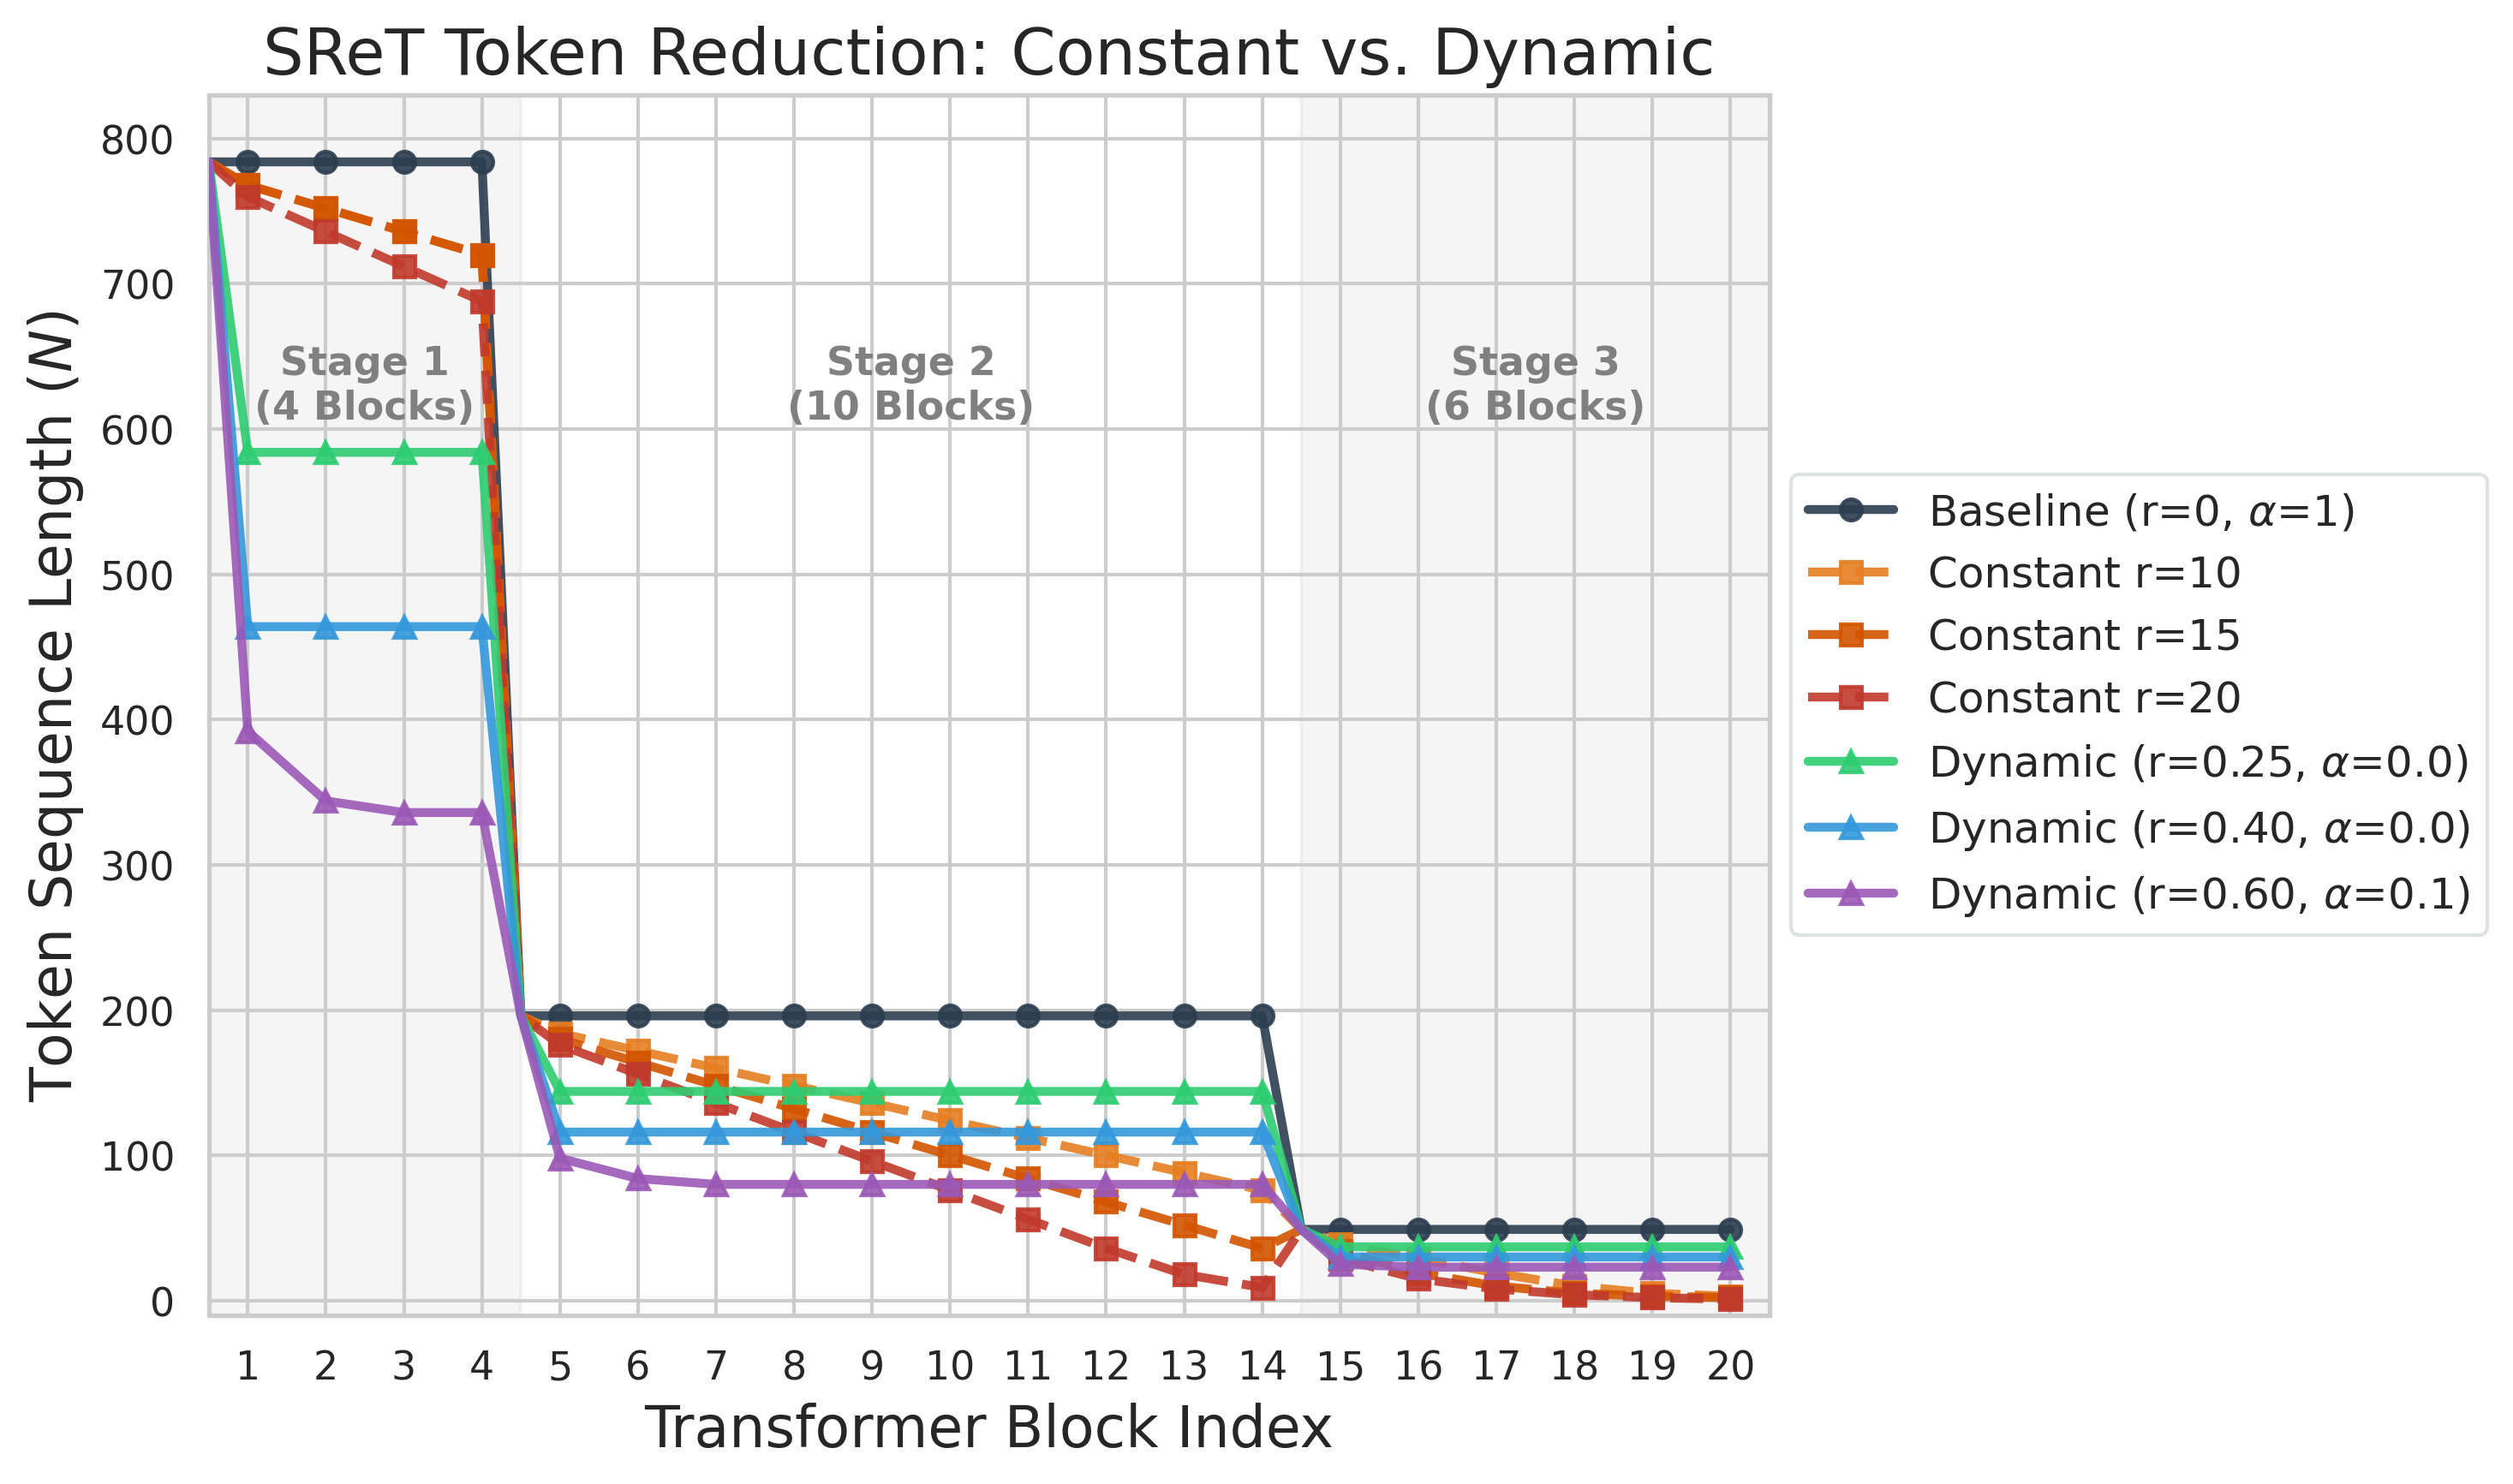

In [17]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 14,            
    'axes.labelsize': 16,       
    'axes.titlesize': 18,       
    'legend.fontsize': 12,      
    'figure.dpi': 300,
    'lines.linewidth': 2.5      
})

x_coords = [0.5, 1, 2, 3, 4, 4.5, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 14.5, 15, 16, 17, 18, 19, 20]

sret_token_progression = {
    "Baseline (r=0, $\\alpha$=1)": [
        784, # stage 1 base
        784, 784, 784, 784, 
        196, # stage 2 base
        196, 196, 196, 196, 196, 196, 196, 196, 196, 196, 
        49,  # stage 3 base
        49, 49, 49, 49, 49, 49
    ],
    "Constant r=10": [
        784, # stage 1 base
        768, 752, 736, 720, 
        196, # stage 2 base
        184, 172, 160, 148, 136, 124, 112, 100, 88, 76, 
        49,  # stage 3 base
        39, 29, 19, 10, 5, 3
    ],
    "Constant r=15": [
        784, # stage 1 base
        768, 752, 736, 720, 
        196, # stage 2 base
        180, 164, 148, 132, 116, 100, 84, 68, 52, 36, 
        49,  # stage 3 base
        34, 19, 10, 5, 3, 2
    ],
    "Constant r=20": [
        784, # stage 1 base
        760, 736, 712, 688, 
        196, # stage 2 base
        176, 156, 136, 116, 96, 76, 56, 36, 18, 9, 
        49,  # stage 3 base
        29, 15, 8, 4, 2, 1
    ],
    "Dynamic (r=0.25, $\\alpha$=0.0)": [
        784, # stage 1 base
        584, 584, 584, 584, 
        196, # stage 2 base
        144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 
        49,  # stage 3 base
        37, 37, 37, 37, 37, 37
    ],
    "Dynamic (r=0.40, $\\alpha$=0.0)": [
        784, # stage 1 base
        464, 464, 464, 464, 
        196, # stage 2 base
        116, 116, 116, 116, 116, 116, 116, 116, 116, 116, 
        49,  # stage 3 base
        30, 30, 30, 30, 30, 30
    ],
    "Dynamic (r=0.60, $\\alpha$=0.1)": [
        784, # stage 1 base
        392, 344, 336, 336, 
        196, # stage 2 base
        98, 84, 80, 80, 80, 80, 80, 80, 80, 80, 
        49,  # stage 3 base
        25, 23, 23, 23, 23, 23
    ]
}

colors = {
    "Baseline (r=0, $\\alpha$=1)": "#2c3e50",      
    "Constant r=10": "#e67e22",               
    "Constant r=15": "#d35400",               
    "Constant r=20": "#c0392b",               
    "Dynamic (r=0.25, $\\alpha$=0.0)": "#2ecc71",
    "Dynamic (r=0.40, $\\alpha$=0.0)": "#3498db",
    "Dynamic (r=0.60, $\\alpha$=0.1)": "#9b59b6" 
}

fig, ax = plt.subplots(figsize=(10, 6))

ax.axvspan(0.5, 4.5, color='gray', alpha=0.08, zorder=0)
ax.axvspan(4.5, 14.5, color='white', alpha=0.0, zorder=0)
ax.axvspan(14.5, 20.5, color='gray', alpha=0.08, zorder=0)

block_marker_indices = [i for i, x in enumerate(x_coords) if x % 1 == 0]

for label, tokens in sret_token_progression.items():
    if "Constant" in label:
        linestyle = '--'
        marker = 's'  # square
    elif "Baseline" in label:
        linestyle = '-'
        marker = 'o'  # circle
    else:
        linestyle = '-'
        marker = '^'  # triangle
        
    ax.plot(x_coords, tokens, label=label, color=colors[label], linestyle=linestyle, marker=marker, markersize=6, markevery=block_marker_indices, alpha=0.9, zorder=5)

ax.text(2.5, 630, 'Stage 1\n(4 Blocks)', ha='center', va='center', fontsize=11, fontweight='bold', color='gray')
ax.text(9.5, 630, 'Stage 2\n(10 Blocks)', ha='center', va='center', fontsize=11, fontweight='bold', color='gray')
ax.text(17.5, 630, 'Stage 3\n(6 Blocks)', ha='center', va='center', fontsize=11, fontweight='bold', color='gray')

ax.set_title('SReT Token Reduction: Constant vs. Dynamic')
ax.set_xlabel('Transformer Block Index')
ax.set_ylabel('Token Sequence Length ($N$)')
ax.set_xticks(range(1, 21))
ax.set_xlim(0.5, 20.5)
ax.set_ylim(-10, 830)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, facecolor='white', edgecolor='#d5dbdb')
fig.tight_layout()
fig.savefig('plots/sret_token_count.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)